# 讲透一个强大算法模型，多项式回归 ！！

https://mp.weixin.qq.com/s/AxxBVUAncZlLM3b5b8lfGA

首先，在数学建模中，「回归」是指通过一些已知的数据，找出一个合适的函数（公式），让它尽可能贴近这些数据点。我们希望这个函数可以用来**预测**未来的数据。

举个简单的例子，你观察一个人每天走的步数和他的体重变化之间的关系，你收集了一些数据（步数，体重变化），你就想找一个公式能描述它们之间的规律。

### 什么是多项式回归？

如果你要找的这个函数是一个**多项式函数**（比如包含$x^2、x^3$ 这些项），这就叫多项式回归。

**举例说明：**

你有一堆点，比如：

|x（步数）|   y（体重变化）|
|---|---|
|1|2.1|
|2|2.9|
|3|3.0|
|4|2.4|
|5|1.0|

这些点如果画出来，发现不是一条直线，而是弯曲的。如果你用一条直线去拟合这些点（这就是**线性回归**），效果很差。但是如果你用一个**二次曲线**（比如$y=a+bx+cx^2$）去拟合，就很贴合。这种拟合方式就叫**多项式回归**。

## 核心原理

我们要找一个函数：  
$y=\beta_0+\beta_1x+\beta_2x^2+...+\beta_dx^d$  
其中：  
- $x$是输入变量（自变量），
- $y$是输出变量（因变量），
- $d$是多项式的阶数（比如二次、三次），
- $\beta_0，\beta_1，...，\beta_d$是我们要找的系数（参数）。

我们有$n$个观测数据点$(x_1,y_1),(x_2,y_2),...,(x_m,y_n)$。  
目标是找到一组参数$\beta$，使得这个多项式尽可能拟合这些点。

### 损失函数

为了拟合得好，我们定义一个衡量拟合程度的函数——**平方误差**(即所有预测误差的平方和)：  
$J(\beta_0,...,\beta_d)=\sum\limits_{i=1}^n (y_i-(\beta_0+\beta_1x_i+\beta_2x_i^2+...+\beta_dx_i^d))^2$  
我们要做的事情就是：**最小化这个误差函数**，也就是让拟合曲线尽可能靠近这些点。  
### 矩阵表示  
为了更方便计算，我们可以将它变成矩阵形式。  
**构造「设计矩阵」X：**  
$$
X=\left[\begin{matrix}
    1&x_1&x_1^2&...&x_1^d \\
    1&x_2&x_2^2&...&x_2^d \\
    \vdots & \vdots & \ddots & \vdots \\
    1&x_n&x_n^2&...&x_n^d \\
    \end{matrix}\right]
$$
这是一个$n*(d+1)$的矩阵。  
**构造参数向量$\beta$：**  
$$
\beta=\left[\begin{matrix}
    \beta_0 \\
    \beta_1 \\
    \beta_2 \\
    \vdots \\
    \beta_d \\
    \end{matrix}\right]
$$  
**构造目标向量$y$：**
$$
y=\left[\begin{matrix}
    y_1 \\
    y_2 \\
    \vdots \\
    y_n \\
    \end{matrix}\right]
$$  
那么预测值就可以写成：  
$\widehat{y}=X\beta$  
平方误差函数可以写成：
$J\beta=(y-X\beta)^T(y-X\beta)$   

### 最小二乘法解

为了让误差最小，我们对$J(\beta)$对$\beta$求导，然后令导数为 0。

对$J(\beta)$求导得：  
$\frac{\partial J}{\partial \beta}=-2X^T(y-X)\beta$  
令导数为 0：  
$X^TX\beta=X^Ty$  
这被称为「正规方程」（Normal Equation）。  
最终我们解出：  
$\beta=(X^TX)^{-1}X^Ty$  
这个公式就是我们要求的参数$\beta$的解。注意，这需要$X^T X$是可逆的。

## 算法流程  
### 步骤 1：收集数据  
你要有一组数据点$(x_1,y_1),(x_2,y_2),...,(x_n,y_n)$ 。  
### 步骤 2：选择多项式的阶数 d
你决定用几次多项式去拟合（比如 d = 2 就是二次曲线）。这个选择非常重要，太低拟合不够，太高会过拟合。  
### 步骤 3：构造设计矩阵 X  
对于每个数据点$x_i$ ，构造一行：  
$[1,x_i,x_i^2,...,X_i^d]$  
得到一个$x*(d+1)$的矩阵$X$。  
### 步骤 4：构造目标向量 y  
就是把所有$y_i$放在一个列向量里。
### 步骤 5：计算参数向量 β
使用公式：  
$\beta=(X^TX)^{-1}X^Ty$  
这个步骤是计算最优拟合参数。
### 步骤 6：预测或绘图  
对于任意新的x，你可以用：  
$\widehat{y}=\beta_0+\beta_1x+\beta_2x^2+...+\beta_dx^d$  
来得到预测值。

## 完整案例

假设我们正在分析一座城市中不同地区**的房价与城市中心距离**之间的关系。

你发现：在靠近市中心时，房价随着距离远离快速下降，但当距离进一步拉远到郊区，房价可能再次上涨（如有学区、安静环境等因素）。也就是说，**房价与距离之间不是线性关系，而是曲线关系**。

这时，用线性回归就无法很好地拟合趋势，而我们将使用**多项式回归**来捕捉这种非线性结构。

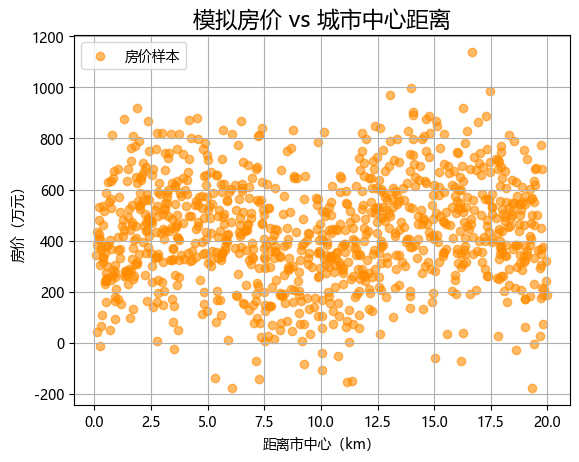

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge, Lasso
import seaborn as sns

# 设置中文字体（如微软雅黑），确保中文正常显示
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

# 距离市中心的距离（km）
X = np.random.uniform(0, 20, 1000)
X = np.sort(X)

# 真实房价规律：模拟一种非线性规律 + 一点噪声
# 假设房价在市中心高，离开后下降，再有些地段略回升
y_true = (
    -0.8 * X**2 + 
    20 * X + 
    300 + 
    100 * np.sin(X / 2) + 
    np.random.normal(0, 200, size=X.shape)
)

# Reshape X 为列向量
X = X.reshape(-1, 1)

plt.scatter(X, y_true, color='darkorange', alpha=0.6, label='房价样本')
plt.title("模拟房价 vs 城市中心距离", fontsize=16)
plt.xlabel("距离市中心（km）")
plt.ylabel("房价（万元）")
plt.legend()
plt.grid(True)
plt.show()

从图中可以看到数据呈明显的非线性关系，并且有一些波动（模拟噪声）。这是典型的非线性拟合场景。

### 构建多项式回归模型（多阶对比）

我们尝试不同的多项式阶数，看看拟合效果。

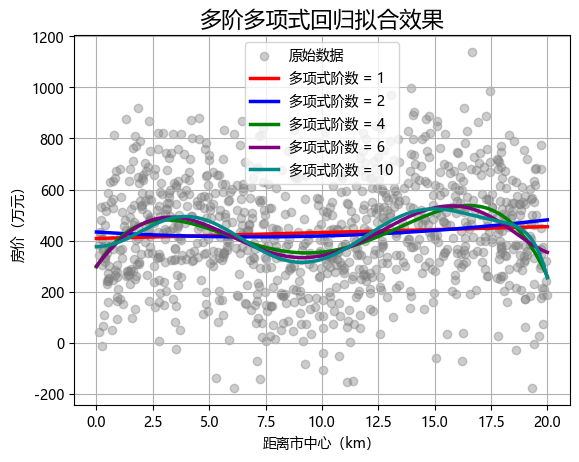

In [2]:
def plot_polynomial_models(degrees, X, y_true):
    X_plot = np.linspace(0, 20, 500).reshape(-1, 1)

    plt.scatter(X, y_true, color='gray', alpha=0.4, label='原始数据')

    colors = ['red', 'blue', 'green', 'purple', 'darkcyan', 'magenta']

    for i, degree in enumerate(degrees):
        model = make_pipeline(
            PolynomialFeatures(degree),
            LinearRegression()
        )
        model.fit(X, y_true)
        y_pred = model.predict(X_plot)
        plt.plot(X_plot, y_pred, color=colors[i % len(colors)], linewidth=2.5,
                 label=f"多项式阶数 = {degree}")

    plt.title("多阶多项式回归拟合效果", fontsize=16)
    plt.xlabel("距离市中心（km）")
    plt.ylabel("房价（万元）")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_polynomial_models([1, 2, 4, 6, 10], X, y_true)

- **1阶（线性回归）**：完全无法捕捉房价的变化。  
- **2~4阶**：逐渐逼近真实趋势。  
- **6阶以上**：可能过拟合。

### 模型评估（训练集 vs 测试集）

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y_true, test_size=0.3, random_state=42)

def evaluate_model(degree):
    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return mse, r2

for d in range(1, 11):
    mse, r2 = evaluate_model(d)
    print(f"多项式阶数 {d:2d} -> MSE: {mse:.2f}, R²: {r2:.3f}")

多项式阶数  1 -> MSE: 39757.96, R²: 0.001
多项式阶数  2 -> MSE: 39573.07, R²: 0.006
多项式阶数  3 -> MSE: 39637.23, R²: 0.004
多项式阶数  4 -> MSE: 37233.89, R²: 0.065
多项式阶数  5 -> MSE: 36996.78, R²: 0.071
多项式阶数  6 -> MSE: 36714.95, R²: 0.078
多项式阶数  7 -> MSE: 36669.61, R²: 0.079
多项式阶数  8 -> MSE: 36391.70, R²: 0.086
多项式阶数  9 -> MSE: 36680.67, R²: 0.079
多项式阶数 10 -> MSE: 36654.94, R²: 0.079


- 随着阶数增加，训练误差会下降，但测试误差可能先下降后上升。
- 这说明高阶模型过拟合了训练集，在测试集上泛化能力下降。

### 交叉验证 + 画出误差趋势


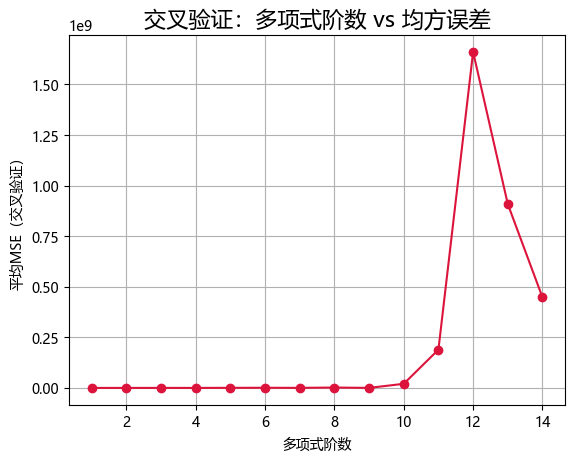

In [9]:
degrees = range(1, 15)
cv_errors = []

for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    mse = -np.mean(cross_val_score(model, X, y_true, cv=5, scoring='neg_mean_squared_error'))
    cv_errors.append(mse)

plt.plot(degrees, cv_errors, marker='o', color='crimson')
plt.title("交叉验证：多项式阶数 vs 均方误差", fontsize=16)
plt.xlabel("多项式阶数")
plt.ylabel("平均MSE（交叉验证）")
plt.grid(True)
plt.show()

图像清晰显示了模型复杂度与误差之间的平衡。

最佳的多项式阶数应该在误差最低点附近（比如 4~6阶）。

### 正则化优化（防止过拟合  
我们使用 **Ridge（L2）** 和**Lasso（L1）** 回归作为优化手段。

d:\Program Files\Tools\miniconda3\envs\PyNN\Lib\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=2.41614e-27): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
d:\Program Files\Tools\miniconda3\envs\PyNN\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.026e+07, tolerance: 4.308e+03
  model = cd_fast.enet_coordinate_descent(


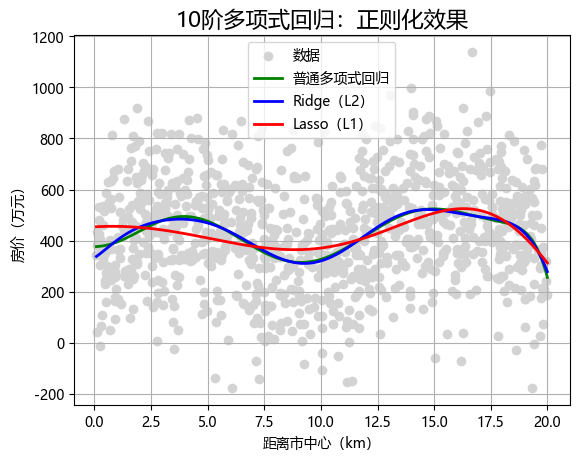

In [10]:
degree = 10
alpha = 10# 正则化强度

# 构造输入特征
poly = PolynomialFeatures(degree)
X_poly = poly.fit_transform(X)

# Ridge 回归
ridge = Ridge(alpha=alpha)
ridge.fit(X_poly, y_true)
y_ridge = ridge.predict(X_poly)

# Lasso 回归
lasso = Lasso(alpha=alpha, max_iter=10000)
lasso.fit(X_poly, y_true)
y_lasso = lasso.predict(X_poly)

# 普通线性回归
linear = LinearRegression()
linear.fit(X_poly, y_true)
y_linear = linear.predict(X_poly)

# 可视化对比
plt.scatter(X, y_true, color='lightgray', label='数据')

plt.plot(X, y_linear, color='green', label='普通多项式回归', linewidth=2)
plt.plot(X, y_ridge, color='blue', label='Ridge（L2）', linewidth=2)
plt.plot(X, y_lasso, color='red', label='Lasso（L1）', linewidth=2)

plt.title("10阶多项式回归：正则化效果", fontsize=16)
plt.xlabel("距离市中心（km）")
plt.ylabel("房价（万元）")
plt.legend()
plt.grid(True)
plt.show()

- 普通回归（无正则化）曲线会有剧烈震荡（典型过拟合）  
- Ridge 和 Lasso 拟合曲线更平滑、合理  
- Lasso 还能自动将部分系数变为 0，起到特征选择的作用

整个案例，用模拟房价案例说明了为什么要使用多项式回归，实现了完整的建模流程：数据处理、模型拟合、可视化、交叉验证、正则化。

引入了 Ridge 和 Lasso 来优化模型的稳定性和泛化能力。